# DSCI235 Final Project

LINK 

# Introduction FIXME
I am interesting in the dataset because how much it relates to my life. I want to look at the relationship between stress and
lifestyle factors, such as notifications received, total screentime, and screen time immediately before bed. The dataset I am using is a Kaggle dataset on Sleep, Screentime and Stress Analysis. The column I am most interested in is the stress level column. 

In [72]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data exploration and cleaning

In [9]:
data = pd.read_csv('SSSdataset.csv')
data.info()

data = data.dropna()
data = data.drop(columns=["user_id"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

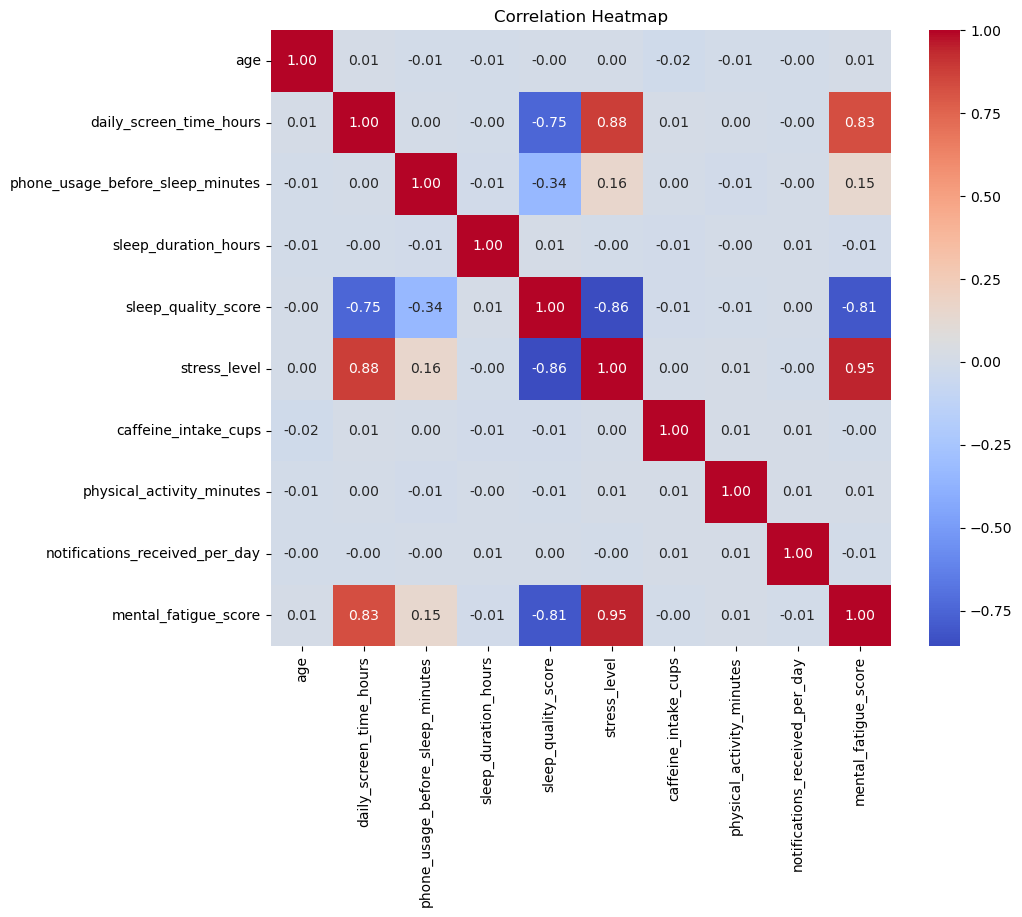

In [10]:
plt.figure(figsize=(10,8))
numeric_data = data.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

I chose to create a heatmap to look at some initial correaltion. Some big things stood out. First of all, age, sleep duration, caffine intake, physical activity minutes, and notifications recieved per day seeminly had no correlation with anything. Daily screentime hours is positivley correlated with sleep quality, something I want to look more into. Mental fatigue score is highly positively correlated with sleep quality, another catgeory I want to explore more. And the last category to show correlation is sleep score wiht a high negative correlation. The problem with heatmaps is there is no way to see categoical data, so categories like occupation and gender will have to be explored futher.

# Examination of Lifestyle Factors on Stress


For this section our target column is sleep quality score.  

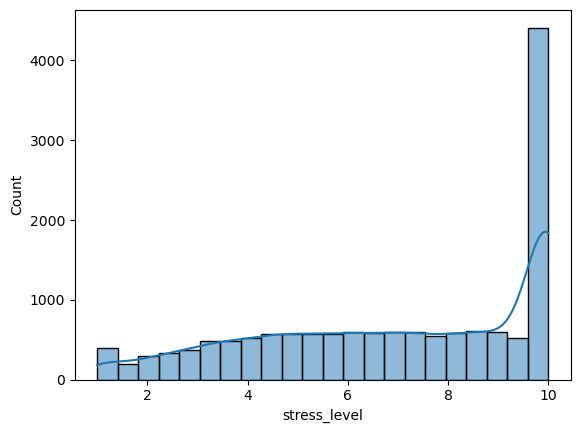

In [23]:
target = 'sleep_quality_score'
sns.histplot(x = data['stress_level'], kde = True)
plt.show()

Stress levels are skewed toward the high end of the scale. There is a noticeable concentration of responses at 10. There is still variability across the full range This indicates that while many individuals report high stress not all individuals report extreme levels.

In [80]:
data['stress_group'] = pd.cut(
    data['stress_level'],
    bins=[0, 5, 8, 10],
    labels=['Low', 'Moderate', 'High'],
    include_lowest=True
)

To make visualization easier in the future, I wanted to seperate the stress responses into three groups: Low, Moderate, and High. We can see from the graph above that the majority of people fall into the high stress levels. This works for my study because I am particularly interested in looking at factors that cause high stress. The rest of the data seems to be split pretty evenly between moderate and low. 

## Categorical Data

### Gender Effect on Stress Levels

In [26]:
print("Male responses: " , sum(data['gender'].isin(["Male"])))
print("Female responses: " , sum(data['gender'].isin(["Female"])))
print("Other responses: " , sum(data['gender'].isin(["Other"])))

Male responses:  7234
Female responses:  7181
Other responses:  585


Looking at the data it seems like we have a pretty even split between men and women. There are less people who chose other but we will still look at them as their own group. 

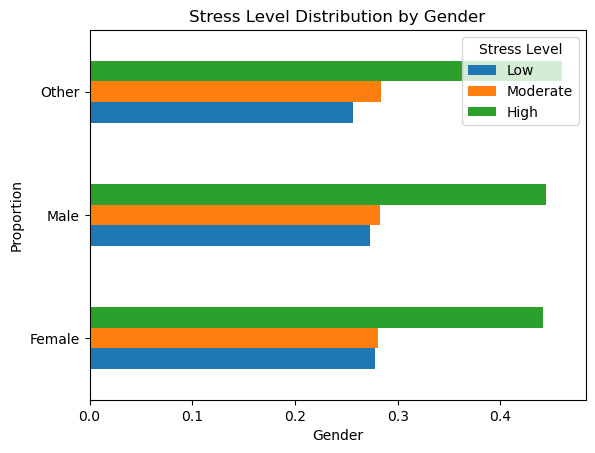

In [29]:
pd.crosstab(data['gender'], data['stress_group'], normalize='index').plot(kind='barh', stacked=False)
plt.title('Stress Level Distribution by Gender')
plt.ylabel('Proportion')
plt.xlabel('Gender')
plt.legend(title='Stress Level')
plt.show()

In [30]:
pd.crosstab(data['gender'], data['stress_group'], normalize='index')

stress_group,Low,Moderate,High
gender,,,
Female,0.278095,0.280741,0.441164
Male,0.272878,0.282416,0.444706
Other,0.256410,0.283761,0.459829


As we saw in the graph just looking at stress levels, people are stressed. There doesnt seem to be a specific gender that are more stressed than others. Males and females both have 44% of their respondants answering high stress, which leaves 54% of the respondants answering low or moderate stress. The other category had 45% fo tehir respondants answering high stress. Overall we can just see that no matter the gender typically about 44% of people fall into the high stress category. This shows gender doesnt seem to have much of an impact on stress

### Age 

In [83]:
data['age_group'] = pd.cut(
    data['age'],
    bins=[18, 25, 35, 50, 65],
    labels=['18-25', '26-35', '36-50', '51-65'],
    include_lowest=True
)

<Axes: xlabel='age_group'>

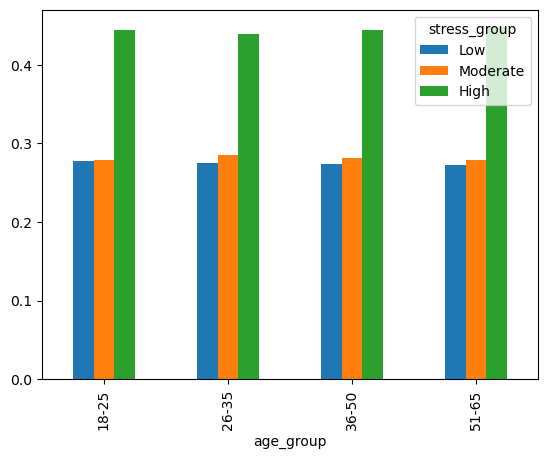

In [85]:
pd.crosstab(data['age_group'], data['stress_group'], normalize='index').plot(kind='bar', stacked=False)

In [38]:
pd.crosstab(data['age_group'], data['stress_group'], normalize='index')

stress_group,Low,Moderate,High
age_group,,,
18-25,0.277398,0.278836,0.443766
26-35,0.275513,0.285363,0.439124
36-50,0.273737,0.282066,0.444198
51-65,0.273188,0.279202,0.447610


We see a very similar seperation as the gender one. Across all ages we see a high stress response about 44% of the time. Its interesting to see such an even split. Though this isn't suprising, I feel like people in this day and age are jsut all around stressed. 

### Occupation!!!!

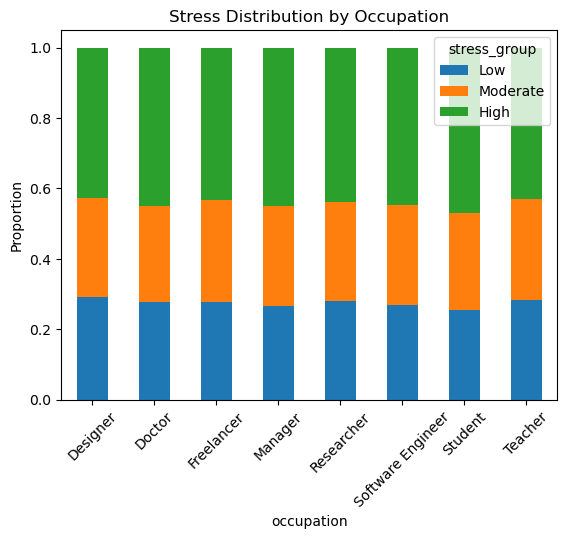

In [99]:
top_occ = data['occupation'].value_counts().nlargest(100).index
filtered = data[data['occupation'].isin(top_occ)]

pd.crosstab(
    filtered['occupation'],
    filtered['stress_group'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Stress Distribution by Occupation')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.show()



Now I wanted to see if theres a difference in stress level among different occupations. The top three most stressed groups are, student manager, and software engineer in that order. Those three being high stress feilds is not suprising to me. What is suprising is Doctor being out of the top three. For me that seems to be a high stress field. It does seem like all the occupation groups ahve similar distributions of high moderate and low stress. While there are differences in groups, the differences are not that large and therefore not that significant. 

Looking at all the categorical data, there doesn't seem to be one specific group of people whoa re more stressed than others. All genders, ages, and occupations are dealing with very similar, high levels of stres. 

## Numerical Data

This is where things get interesting. We didn't see much correlation between different groups of people (age, genders, and occupation), but now were are going to look at numerical data. Specifically, screen time, phone use immediently before bed, mental fatigue, and sleep quality. If you look back on our heatmap these are the catgeories that had some sort of corelation with stress levels. Therefore, we own them more looking into. 

### Screen Time

Screen time is a very intersting category. Social media has become such a huge part of everyones lives. There is seemingly no escaping it. I am curious what that kind of constant stimulation does to peoples stress levels. 

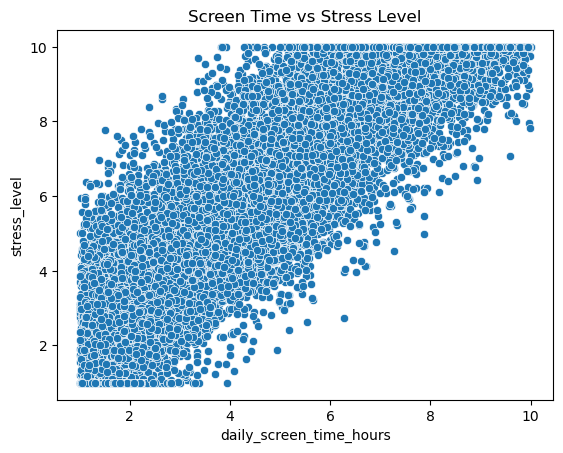

In [43]:
sns.scatterplot(x='daily_screen_time_hours', y='stress_level', data=data)
plt.title('Screen Time vs Stress Level')
plt.show()

In [45]:
data[['daily_screen_time_hours', 'stress_level']].corr()

,daily_screen_time_hours,stress_level
daily_screen_time_hours,1.000000,0.879001
stress_level,0.879001,1.000000


Looking at the graph above, you can see a huge correlation between hours spent on screens and stress levels. This is to be expected as we saw a pretty big correaltion between these on the heat map. 

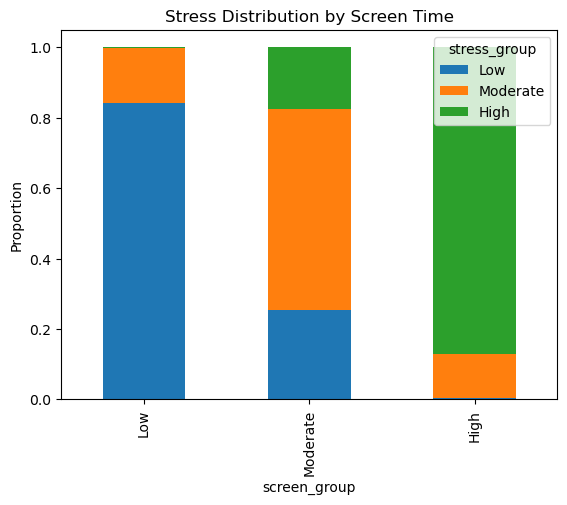

In [50]:
data['screen_group'] = pd.cut(
    data['daily_screen_time_hours'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Moderate', 'High'],
    include_lowest=True
)
pd.crosstab(
    data['screen_group'], 
    data['stress_group'], 
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Stress Distribution by Screen Time')
plt.ylabel('Proportion')
plt.show()

Looking at the porportion of answers only furthers what we seem to already see. Individuals with low screen time report overwhelmingly low stress levels, with very few experiencing high stress. In contrast, those in the high screen time group show a dramatically higher proportion of high stress, with very few individuals reporting low stress. This suggests a strong association between increased screen time and elevated stress levels. This si clearly the highest correlation we have seen so far. As screen time goes up, its clear to see that stress levels also go up. 

### Phone Use Before Bed


Phone use goes along well with screen time. So its understandable that they would show us the same ideas. 

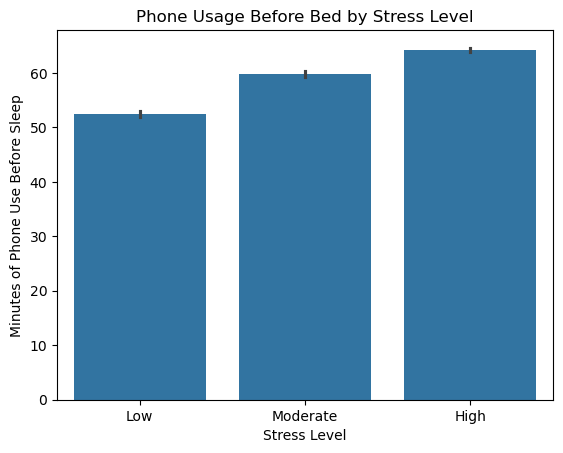

In [63]:
sns.barplot(
    x='stress_group',
    y='phone_usage_before_sleep_minutes',
    data=data,
    errorbar='se'
)

plt.title('Phone Usage Before Bed by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Minutes of Phone Use Before Sleep')
plt.show()

And I mentioned before, phone usage is going to show a similar trend as screen time. And it does! We see a positive correaltion with more screen time right before bed leads to higher stress levels. And I think this tells us something interesting but its not as big of a correlation as screen time as a whole. Being a 22 year old stressed out student, I know a lot of people who scroll on their phones right before bed. They do it in a way to wind down and prepare to fall asleep but clearly it is doing the oppoisite. 

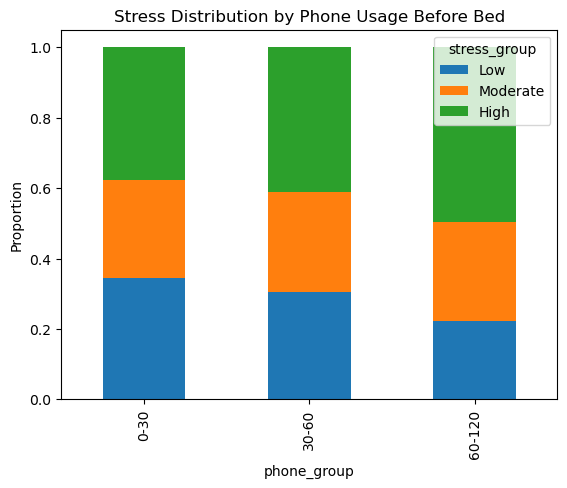

In [65]:
data['phone_group'] = pd.cut(
    data['phone_usage_before_sleep_minutes'],
    bins=[0, 30, 60, 120, 180],
    labels=['0-30', '30-60', '60-120', '120+'],
    include_lowest=True
)
pd.crosstab(
    data['phone_group'],
    data['stress_group'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Stress Distribution by Phone Usage Before Bed')
plt.ylabel('Proportion')
plt.show()

There is a gradual increase in the proportion of high stress as phone usage before bed increases. Individuals who use their phones for 60 to 120 minutes before sleep show the highest levels of stress while those with lower usage tend to have a more balanced stress distribution.

### Mental Fatigue 

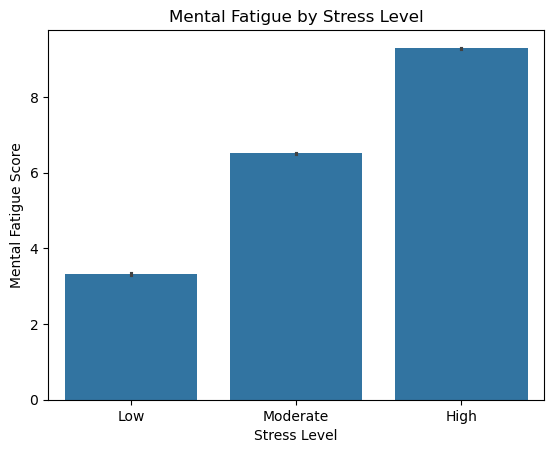

In [73]:
sns.barplot(x='stress_group', y='mental_fatigue_score', data=data, errorbar='se')
plt.title('Mental Fatigue by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Mental Fatigue Score')
plt.show()

We can see from this graph that mental fatigue has a big positive correlation with stress levels. This is pretty intuative, it makes sense that someone woukd have high levels of stress if they also have high levels of mental fatigue. 

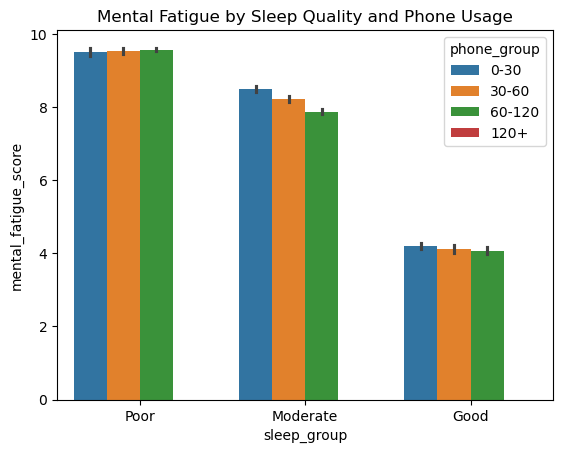

In [74]:
sns.barplot(
    x='sleep_group',
    y='mental_fatigue_score',
    hue='phone_group',
    data=data
)
plt.title('Mental Fatigue by Sleep Quality and Phone Usage')
plt.show()

Mental fatigue varies a lot across sleep quality levels. There are people reporting poor sleep experiencing substantially higher fatigue than those with good sleep. While increased phone usage before bed is associated with slightly higher fatigue within each sleep group. These differences are relatively small compared to the overall effect of sleep quality

### Sleep impact on Stress

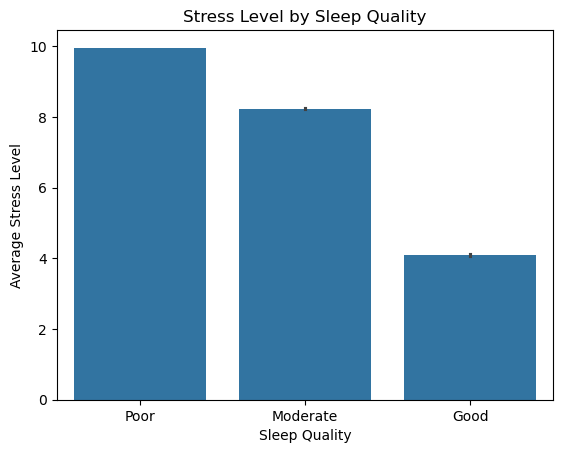

In [67]:
sns.barplot(x='sleep_group', y='stress_level', data=data, errorbar='se')
plt.title('Stress Level by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Average Stress Level')
plt.show()

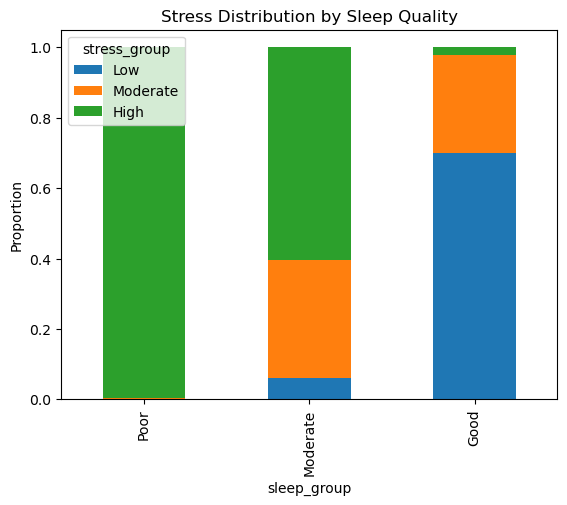

In [68]:
pd.crosstab(
    data['sleep_group'],
    data['stress_group'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Stress Distribution by Sleep Quality')
plt.ylabel('Proportion')
plt.show()

From the first graph we can see there is a strong negative relationship between sleep quality and stress level. People who report poorer sleep have substantially higher stress. Based on the second graph, stress varies dramatically across sleep quality groups. Individuals with poor sleep are entirely in the high stress category while those with good sleep are mostly in the low stress category.

### Combo of factors 

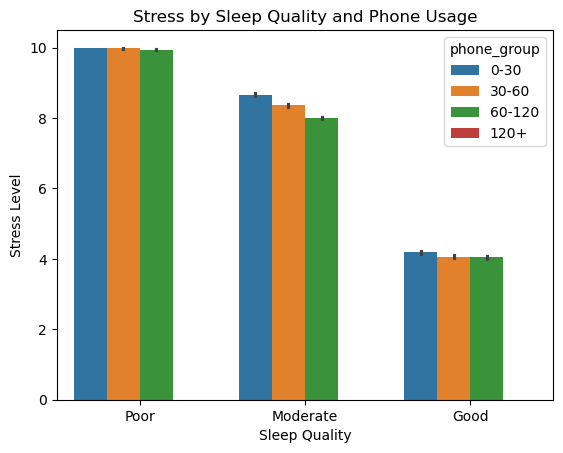

In [75]:
sns.barplot(
    x='sleep_group',
    y='stress_level',
    hue='phone_group',
    data=data,
    errorbar='se'
)

plt.title('Stress by Sleep Quality and Phone Usage')
plt.xlabel('Sleep Quality')
plt.ylabel('Stress Level')
plt.show()

Sleep quality is the primary factor associated with stress levels. Individuals reporting poor sleep experiencing consistently high stress regardless of phone usage. While phone usage before bed shows minor variation within sleep groups its effect is smaller compared to the dominant influence of sleep quality.

<Axes: xlabel='sleep_group', ylabel='stress_level'>

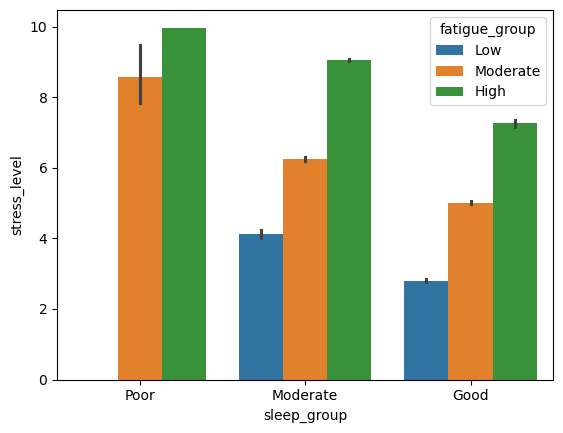

In [78]:
data['fatigue_group'] = pd.cut(
    data['mental_fatigue_score'],
    bins=[0, 4, 7, 10],
    labels=['Low', 'Moderate', 'High']
)

sns.barplot(
    x='sleep_group',
    y='stress_level',
    hue='fatigue_group',
    data=data
)

Stress changes based on both sleep quality and mental fatigue. People who sleep worse tend to have higher stress, and as mental fatigue increases, stress also goes up within each sleep group. Even for people who sleep well, those who feel more mentally tired still report much higher stress

## Final Takeaways

Overall, the biggest thing that stood out is how important sleep is. Out of everything I looked at, sleep quality had the strongest connection to stress. People with poor sleep were dealing with high stress, while people who slept well had much lower stress. Screen time and phone usage before bed did have some effect, but they didn’t matter nearly as much once sleep was taken into account. It seems like those habits might mess with stress mostly because they mess with sleep.

Another big takeaway is how closely stress and mental fatigue are connected. As stress goes up, fatigue goes up a lot too, and that relationship was really clear. Even people who reported good sleep still had higher stress if they were really mentally tired, which shows that fatigue plays its own role too. So overall, stress isn’t coming from just one thing it’s more like a combination of sleep, daily habits, and mental exhaustion all working together.